**1 - Import des bibliotèques**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
pd.set_option("display.max_columns",100)
from keras.models import Sequential
from keras.layers import Dense

**2 - Chargement des données**

In [2]:
df1=pd.read_csv("../data/train.csv")
df2=pd.read_csv("../data/test.csv")

In [3]:
df = pd.concat([df1, df2], ignore_index=True)

**3 - Exploration des données**

In [4]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   str    
 4   Sex          1309 non-null   str    
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   str    
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    str    
 11  Embarked     1307 non-null   str    
dtypes: float64(3), int64(4), str(5)
memory usage: 122.8 KB


In [6]:
df.isnull().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

In [7]:
df.shape

(1309, 12)

**4 - EDA**

In [8]:
df.Name.value_counts()

Name
Connolly, Miss. Kate                                   2
Kelly, Mr. James                                       2
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
                                                      ..
Spector, Mr. Woolf                                     1
Oliva y Ocana, Dona. Fermina                           1
Saether, Mr. Simon Sivertsen                           1
Ware, Mr. Frederick                                    1
Peter, Master. Michael J                               1
Name: count, Length: 1307, dtype: int64

In [10]:
df["Title"]=df["Name"].str.extract("([A-Za-z]+)\.",expand=False)
df['Title']=df['Title'].replace(['Ms','Mlle'],'Miss')
df['Title']=df['Title'].replace(['Mme','Countess','Lady','Dona'],'Mrs')
df['Title']=df['Title'].replace(['Dr','Major','Col','Capt','Sir','Rev','Jonkheer','Don'],'Mr')

<Axes: xlabel='count', ylabel='Title'>

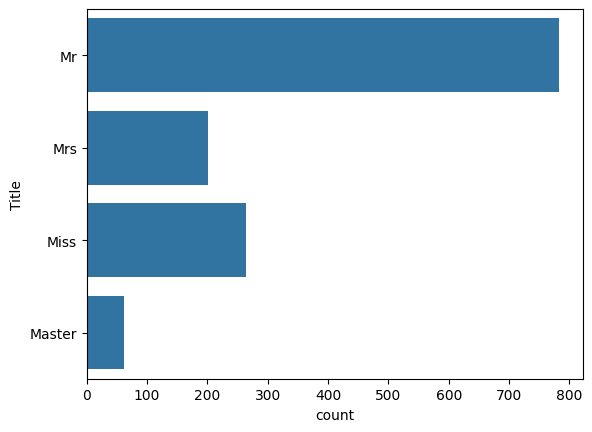

In [11]:
df['Title'].value_counts()
sns.countplot(df["Title"])

In [12]:
df["Age"] = df["Age"].fillna(df.groupby("Title")["Age"].transform("median"),inplace=True)

In [13]:
del df["Cabin"]

In [14]:
df["Fare"] = df["Fare"].fillna(df["Fare"].median(),inplace=True)

In [15]:
df['Family']=df['SibSp']+df['Parch']+1

<Axes: xlabel='Embarked', ylabel='count'>

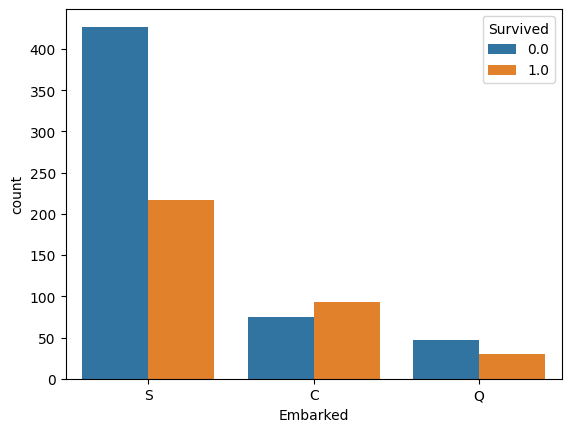

In [16]:
sns.countplot(x = df["Embarked"], hue = df["Survived"], data=df)

In [17]:
df["Embarked"]=df["Embarked"].fillna("S")

In [18]:
df.drop(['Ticket'],axis=1,inplace=True)

In [19]:
df.drop("Name",axis=1,inplace=True)

In [20]:
df=pd.get_dummies(df,drop_first=True)

In [21]:
df.shape

(1309, 14)

In [22]:
x,y=df[:891].drop("Survived",axis=1),df[:891][["Survived"]]

In [23]:
x.shape, y.shape

((891, 13), (891, 1))

**5 - Prédiction**

In [24]:
def result_func(model,count):
    predict_x=model.predict(df[891:].drop("Survived",axis=1))
    result_dataset=pd.DataFrame()
    result_dataset["PassengerId"]=df[891:]["PassengerId"]
    result_dataset["Predict"]=predict_x
    result_dataset["Survived"]=result_dataset["Predict"].map(lambda s:1 if s>=0.5 else 0 )
    print(result_dataset["Survived"].value_counts().plot.bar())
    result_dataset.drop("Predict",axis=1).to_csv("../data/titanic_deep_learning_result_model{}.csv".format(count),index=False)
    return result_dataset

In [25]:
model=Sequential()
model.add(Dense(13,activation='relu'))
model.add(Dense(9,activation='relu'))
model.add(Dense(6,activation='relu'))
model.add(Dense(3,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [26]:
model.compile(loss='binary_crossentropy',optimizer="adam",metrics=["accuracy"])

In [27]:
model.fit(x,y,epochs=200,batch_size=10,verbose=1)

Epoch 1/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3838 - loss: 90.8441   
Epoch 2/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 897us/step - accuracy: 0.5713 - loss: 2.0978
Epoch 3/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 893us/step - accuracy: 0.6105 - loss: 0.6677
Epoch 4/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 902us/step - accuracy: 0.6072 - loss: 0.6584
Epoch 5/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 908us/step - accuracy: 0.6128 - loss: 0.6606
Epoch 6/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 902us/step - accuracy: 0.6139 - loss: 0.6394
Epoch 7/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 903us/step - accuracy: 0.6162 - loss: 0.6467
Epoch 8/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 947us/step - accuracy: 0.6184 - loss: 0.6383
Epoch 9/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 961us/step - accuracy: 0.6195 - loss: 0.6393
Epoch 10/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 912us/step - accuracy: 0.6184 - loss: 0.6434
Epoch 11/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 919us/step - accuracy: 0.6218 - loss: 0.6268
Epoch 12/200
90/90 ━━━━━━━━━━━━━━━━━━━━

In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 13)             │           182 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │           126 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            21 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,181 (4.62 KB)

 Trainable params: 393 (1.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 788 (3.08 KB)

In [29]:
scores=model.evaluate(x, y)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8114 - loss: 0.4604 


In [30]:
print("%s: %.2f%%" % (model.metrics_names[1],scores[1]*100))

compile_metrics: 81.14%


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Axes(0.125,0.11;0.775x0.77)


,PassengerId,Predict,Survived
891,892,0.303438,0
892,893,0.721971,1
893,894,0.197761,0
894,895,0.316491,0
895,896,0.838771,1
...,...,...,...
1304,1305,0.382950,0
1305,1306,0.972970,1
1306,1307,0.309216,0
1307,1308,0.383687,0


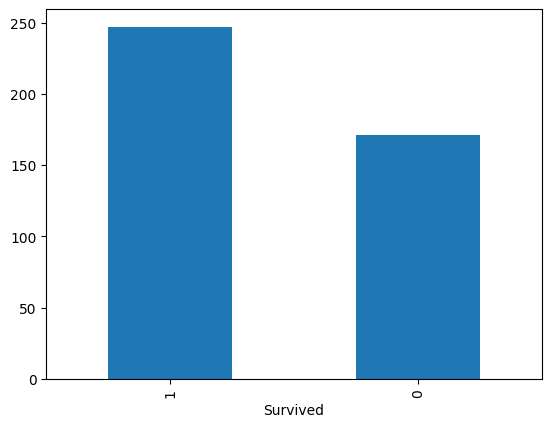

In [31]:
result_func(model,1)

In [32]:
history=model.fit(x,y,epochs=180,batch_size=10,verbose=1)

Epoch 1/180
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8171 - loss: 0.4221  
Epoch 2/180
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 966us/step - accuracy: 0.8182 - loss: 0.4181
Epoch 3/180
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 994us/step - accuracy: 0.8238 - loss: 0.4131
Epoch 4/180
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 937us/step - accuracy: 0.8137 - loss: 0.4321
Epoch 5/180
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 973us/step - accuracy: 0.8193 - loss: 0.4185
Epoch 6/180
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8092 - loss: 0.4185  
Epoch 7/180
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8238 - loss: 0.4090  
Epoch 8/180
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 926us/step - accuracy: 0.8148 - loss: 0.4182
Epoch 9/180
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 940us/step - accuracy: 0.8047 - loss: 0.4285
Epoch 10/180
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 946us/step - accuracy: 0.8148 - loss: 0.4222
Epoch 11/180
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 961us/step - accuracy: 0.8070 - loss: 0.4232
Epoch 12/180
90/90 ━━━━━━━━━━━━━━━━━━━━ 0

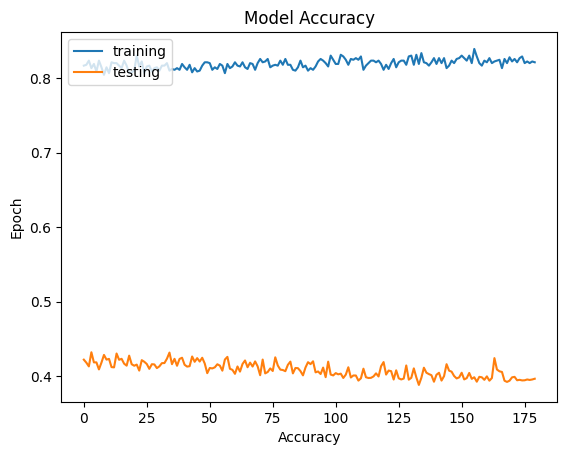

In [33]:
fig1=plt.figure(1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["loss"])
plt.title("Model Accuracy")
plt.xlabel("Accuracy")
plt.ylabel("Epoch")
plt.legend(["training", "testing"], loc= "upper left")

In [34]:
model=Sequential()
model.add(Dense(14,activation='relu'))
model.add(Dense(9,activation='relu'))
model.add(Dense(4,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [35]:
model.compile(loss='binary_crossentropy',optimizer="adam",metrics=["accuracy"])

In [36]:
model.fit(x,y,validation_split=0.2,epochs=150,batch_size=10,verbose=2)

Epoch 1/150
72/72 - 1s - 13ms/step - accuracy: 0.5506 - loss: 1.7209 - val_accuracy: 0.7039 - val_loss: 0.6381
Epoch 2/150
72/72 - 0s - 2ms/step - accuracy: 0.6081 - loss: 0.7312 - val_accuracy: 0.3911 - val_loss: 0.9033
Epoch 3/150
72/72 - 0s - 2ms/step - accuracy: 0.6124 - loss: 0.7170 - val_accuracy: 0.7095 - val_loss: 0.6144
Epoch 4/150
72/72 - 0s - 2ms/step - accuracy: 0.6011 - loss: 0.7146 - val_accuracy: 0.6369 - val_loss: 0.7596
Epoch 5/150
72/72 - 0s - 2ms/step - accuracy: 0.6503 - loss: 0.6761 - val_accuracy: 0.6816 - val_loss: 0.7658
Epoch 6/150
72/72 - 0s - 2ms/step - accuracy: 0.6447 - loss: 0.6567 - val_accuracy: 0.6592 - val_loss: 1.4414
Epoch 7/150
72/72 - 0s - 2ms/step - accuracy: 0.6643 - loss: 0.6499 - val_accuracy: 0.7039 - val_loss: 0.6361
Epoch 8/150
72/72 - 0s - 2ms/step - accuracy: 0.6784 - loss: 0.6057 - val_accuracy: 0.7207 - val_loss: 0.5461
Epoch 9/150
72/72 - 0s - 2ms/step - accuracy: 0.6868 - loss: 0.5990 - val_accuracy: 0.6480 - val_loss: 0.9908
Epoch 10/

In [37]:
scores=model.evaluate(x,y)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8092 - loss: 0.4412 


In [38]:
print("%s: %.2f%%" % (model.metrics_names[1],scores[1]*100))

compile_metrics: 80.92%


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Axes(0.125,0.11;0.775x0.77)


,PassengerId,Predict,Survived
891,892,0.023974,0
892,893,0.059770,0
893,894,0.015953,0
894,895,0.037723,0
895,896,0.164244,0
...,...,...,...
1304,1305,0.024403,0
1305,1306,0.997813,1
1306,1307,0.010828,0
1307,1308,0.024377,0


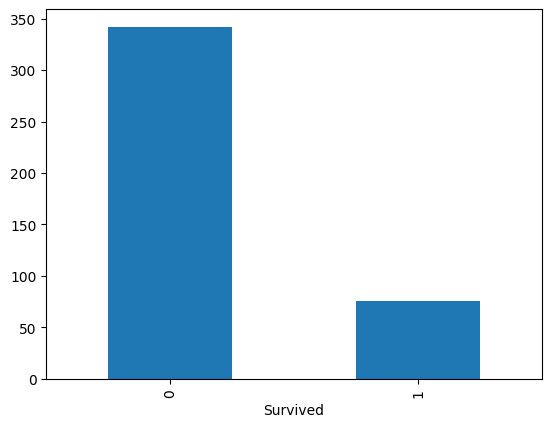

In [39]:
result_func(model,2)

In [40]:
history=model.fit(x,y,validation_split=0.2,epochs=200,batch_size=10,verbose=2)

Epoch 1/200
72/72 - 0s - 2ms/step - accuracy: 0.7992 - loss: 0.4385 - val_accuracy: 0.8101 - val_loss: 0.3934
Epoch 2/200
72/72 - 0s - 2ms/step - accuracy: 0.8034 - loss: 0.4368 - val_accuracy: 0.8380 - val_loss: 0.4011
Epoch 3/200
72/72 - 0s - 2ms/step - accuracy: 0.8062 - loss: 0.4624 - val_accuracy: 0.8045 - val_loss: 0.4745
Epoch 4/200
72/72 - 0s - 2ms/step - accuracy: 0.7921 - loss: 0.4431 - val_accuracy: 0.8212 - val_loss: 0.3964
Epoch 5/200
72/72 - 0s - 2ms/step - accuracy: 0.7949 - loss: 0.4468 - val_accuracy: 0.7877 - val_loss: 0.4099
Epoch 6/200
72/72 - 0s - 2ms/step - accuracy: 0.7935 - loss: 0.4583 - val_accuracy: 0.7765 - val_loss: 0.4332
Epoch 7/200
72/72 - 0s - 2ms/step - accuracy: 0.8006 - loss: 0.4297 - val_accuracy: 0.8268 - val_loss: 0.4251
Epoch 8/200
72/72 - 0s - 2ms/step - accuracy: 0.8146 - loss: 0.4235 - val_accuracy: 0.7877 - val_loss: 0.4113
Epoch 9/200
72/72 - 0s - 2ms/step - accuracy: 0.7949 - loss: 0.4800 - val_accuracy: 0.8324 - val_loss: 0.4384
Epoch 10/2

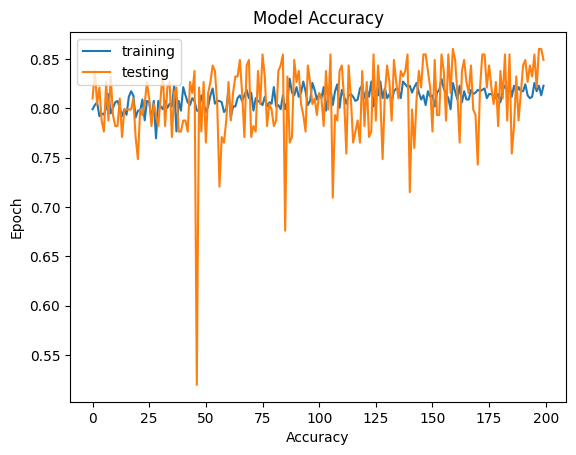

In [41]:
fig1=plt.figure(1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.xlabel("Accuracy")
plt.ylabel("Epoch")
plt.legend(["training", "testing"], loc= "upper left")

<function matplotlib.pyplot.show(close=None, block=None)>

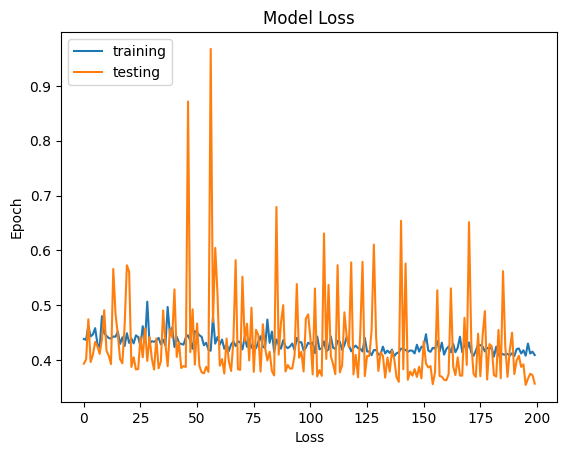

In [42]:
fig1=plt.figure(2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model Loss")
plt.xlabel("Loss")
plt.ylabel("Epoch")
plt.legend(["training", "testing"], loc= "upper left")

plt.show